# Plot Training Logs

**Plot the training logs of a model you have trained.** 

This notebook plots the Learning Rate (Eta), the Exploration Rate (Epsilon), the Reward by Episode and the Loss by Episode as a function of the episode.

Command to Pip Install pandas included.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [14]:
#Add path to model you have trained
PATH = "../models/0609_1955_FrozenDQNAgentBase"
logs = pd.read_csv(os.path.join(PATH,"log.csv"))
logs.tail()

,Time,Step,Episode,Loss,Reward,Eta,Epsilon,Action
9995,46.51,9996,2722,9.924,0.0,0.001,0.05642,1
9996,46.51,9997,2722,4.243,0.0,0.001,0.05641,1
9997,46.52,9998,2723,7.916,0.0,0.001,0.05641,1
9998,46.52,9999,2723,6.617,0.0,0.001,0.05641,1
9999,46.52,10000,2723,7.303,0.0,0.001,0.05640,1


In [15]:
logs_by_episode = logs.groupby('Episode').sum('Reward').reset_index()
logs_by_episode.head()

,Episode,Time,Step,Loss,Reward,Eta,Epsilon,Action
0,0,12.86,105,0.0,0.0,0.014,13.9569,24
1,1,6.54,126,0.0,0.0,0.007,6.9437,12
2,2,13.36,399,0.0,0.0,0.014,13.8185,19
3,3,6.98,273,0.0,0.0,0.007,6.8749,12
4,4,13.09,637,0.0,0.0,0.013,12.7072,17


In [16]:
def plot_logs(logs, title):

    logs_by_episode = logs.groupby('Episode').sum('Reward').reset_index()


    fig, axs = plt.subplots(2,2)


    fig.suptitle(title, fontsize=14)


    #Subplot #1
    axs[0,0].plot(logs["Episode"], logs['Eta']);
    axs[0,0].set_ylabel('Eta')
    axs[0,0].set_xlabel('Episode')
    axs[0,0].set_yscale('log')

    #Subplot #2:
    axs[0,1].plot(logs["Episode"], logs['Epsilon']);
    axs[0,1].set_ylabel('Epsilon')
    axs[0,1].set_xlabel('Episode')
    #axs[0,1].set_yscale('log')

    #Subplot #3:
    axs[1,0].plot(logs_by_episode["Episode"], logs_by_episode['Reward']);
    axs[1,0].set_ylabel('Reward by Episode')
    axs[1,0].set_xlabel('Episode')
    #axs[1,0].set_yscale('log')


    #Subplot #4:
    axs[1,1].plot(logs_by_episode["Episode"], logs_by_episode['Loss']);
    axs[1,1].set_ylabel('Loss by Episode')
    axs[1,1].set_xlabel('Episode')
    #axs[1,1].set_yscale('log')

    fig.tight_layout()

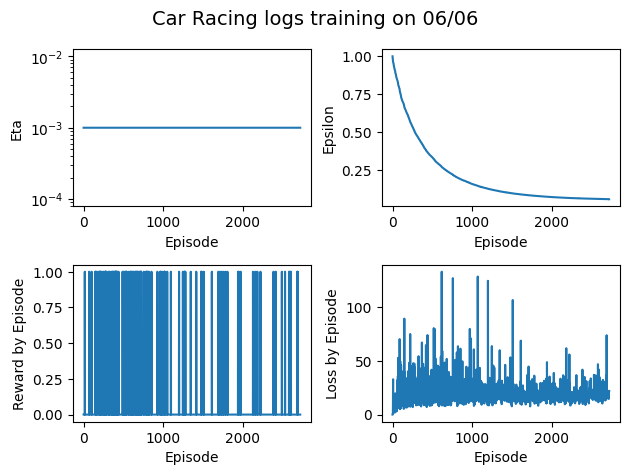

In [17]:
plot_logs(logs, 'Car Racing logs training on 06/06')

### Episode length (in steps)

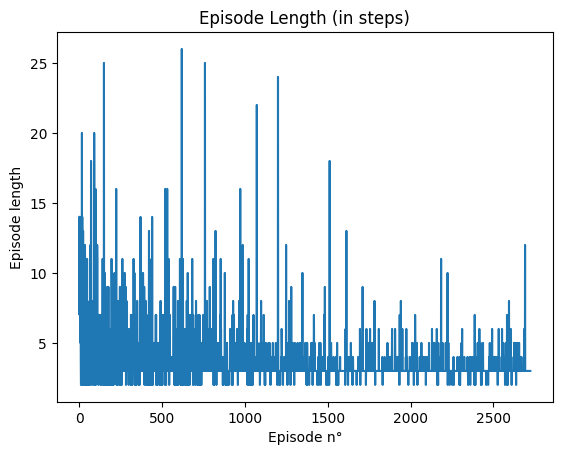

In [18]:
logs_by_episode = logs.groupby('Episode').count()
ax = logs_by_episode['Time'].plot()
ax.set_title('Episode Length (in steps)')
ax.set_xlabel('Episode n°')
ax.set_ylabel('Episode length');

### Action pdf as a function of episode

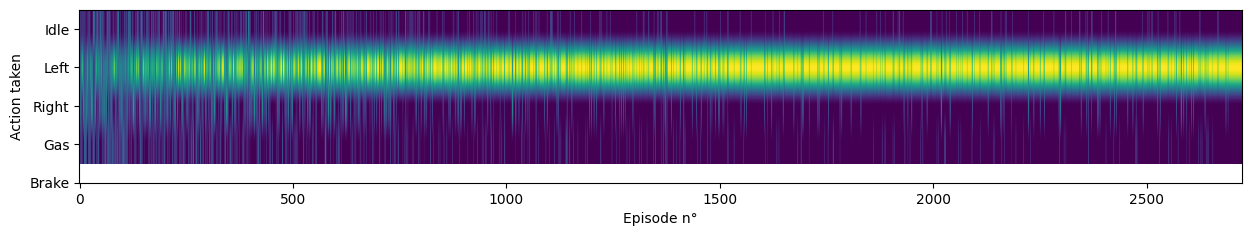

In [19]:
action_count_per_ep = logs[['Episode', 'Action']].groupby('Episode').value_counts(normalize=True).unstack(level=-1)
action_count_per_ep[action_count_per_ep.isna()] = 0
neps = action_count_per_ep.index.max()
fig, ax = plt.subplots()
ax.imshow(np.array(action_count_per_ep).T, aspect=neps//30)
fig.set_size_inches(w=15, h=4)


# Frozen Lake
ax.set_yticks([0,1,2,3])
ax.set_yticklabels(['Left', 'Down', 'Right', 'Up'])

# # Car Race
# ax.set_yticks([0,1,2,3,4])
# ax.set_yticklabels(['Idle', 'Left', 'Right', 'Gas', 'Brake'])

ax.set_xlabel('Episode n°')
ax.set_ylabel('Action taken');

#### Graphing the reward time series for each episode 
(see if at least the model is progressing)

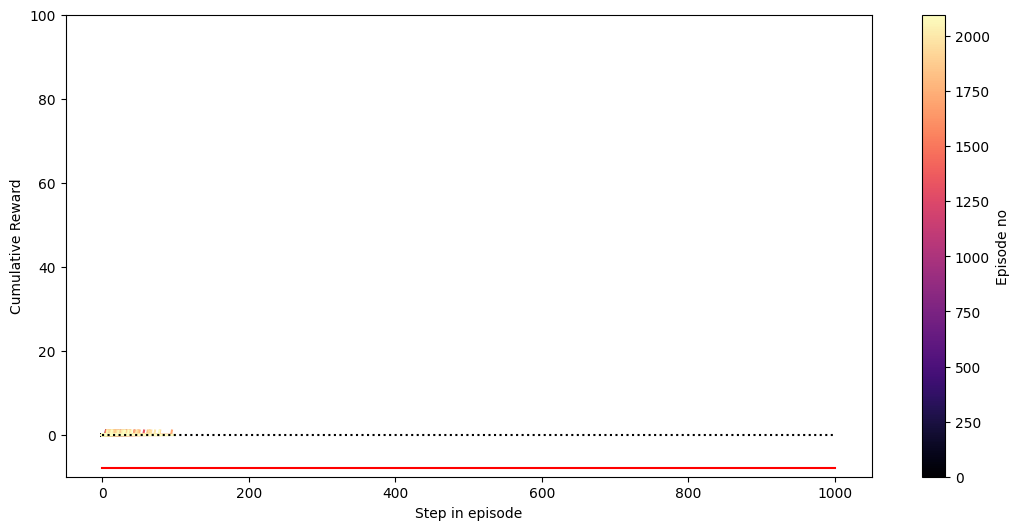

In [12]:
import matplotlib as mpl
import matplotlib.cm as cm 


fig, ax = plt.subplots()
neps = logs['Episode'].max()
cmap = cm.magma

for episode in range(neps):
    rewards_ep = logs[logs['Episode'] == episode]['Reward'].cumsum().to_numpy()
    ax.plot(rewards_ep, color=cmap(episode/neps))

ax.plot([0, 1000], [-8, -8], 'r')
ax.plot([0, 1000], [0, 0], 'k:')

ax.set_xlabel('Step in episode')
ax.set_ylabel('Cumulative Reward')
ax.set_ylim([-10,100])
fig.set_size_inches(w=13, h=6)

norm = mpl.colors.Normalize(vmin=0, vmax=neps)
fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
             ax=ax, label='Episode no')